## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
- Regression: Used for quantitative data and involves drawing a trend line.
- Classification: used for qualitative data and uses decisino boundaries to classify.
2. What is a confusion table? What does it help us understand about a model's performance?
- A confusion table displays the # of correct predictions, Type 1, and Type 2 errors. It involves (True Positive, True Negative, False Positive, and False Negative).
3. What does the SSE quantify about a particular model?
- The sum of squares error is used to measure model accuracy and quantifies the error by measuring the total squared deviation between observed and predicted values in a model.
4. What are overfitting and underfitting?
- Overfitting is trainging the data so much that it fits every data point, but when you give it new one sthey aren't representative. Underfitting is the model is so vague it doesn't help at all.
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
- By using a combination of training and evaluation, you can accuractely determine if the model is a good fit for the data. The same applies for choosing a proper k.
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Classification gives definitive, clear answers but fails to report how confident it is. Predicting the class label is vice versa.


**Q2.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for evaluation.
4. Use the $k$NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [25]:
import pandas as pd
url=('https://raw.githubusercontent.com/nickgoering/KNN/refs/heads/main/data/USA_cars_datasets.csv')
df=pd.read_csv(url)
df.head()
# Q2.1 drop all variables except: price, year, mileage
df.drop(['Unnamed: 0', 'brand','model', 'title_status','color','vin','lot','state','country','condition'], axis=1, inplace=True)
df.shape
df.head()
#Q2.2 maxmin normalize year and mileage
min_year=df['year'].min()
max_year=df['year'].max()
min_mileage=df['mileage'].min()
max_mileage=df['mileage'].max()
min_price=df['price'].min()
max_price=df['price'].max()

cols = ['year', 'mileage','price'] # Define 'cols' here
for col in cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
df








,price,year,mileage
0,0.074205,0.744681,0.269287
1,0.034146,0.808511,0.187194
2,0.063015,0.957447,0.038892
3,0.294464,0.872340,0.063016
4,0.326266,0.957447,0.006537
...,...,...,...
2494,0.091873,0.978723,0.023193
2495,0.108363,0.957447,0.033944
2496,0.108363,0.957447,0.031037
2497,0.108363,0.957447,0.031983


k = 3, MSE = 0.0205


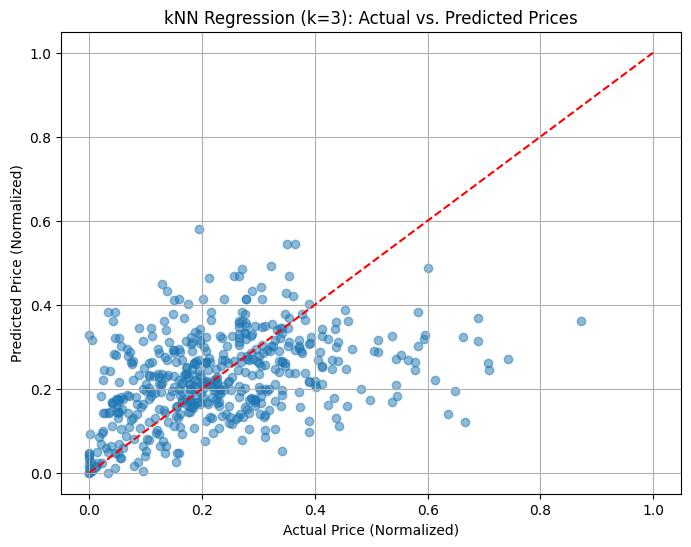

k = 10, MSE = 0.0163


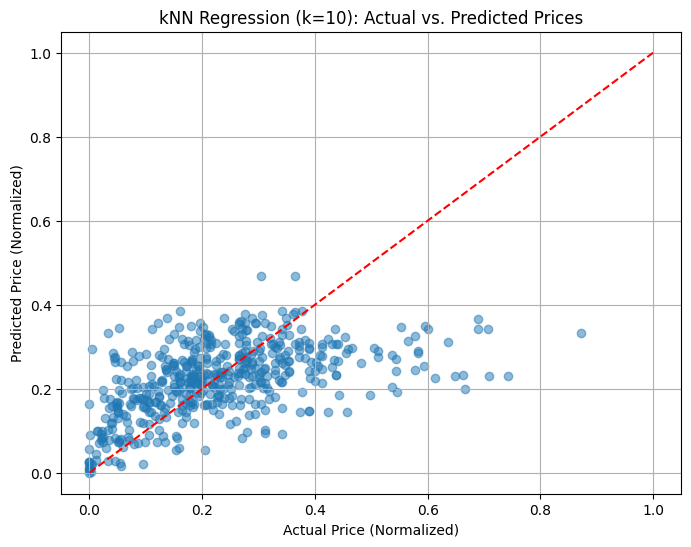

k = 25, MSE = 0.0156


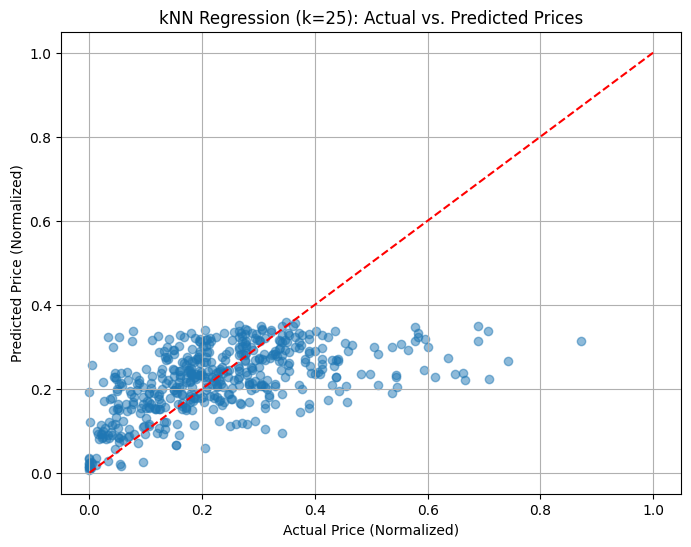

k = 50, MSE = 0.0153


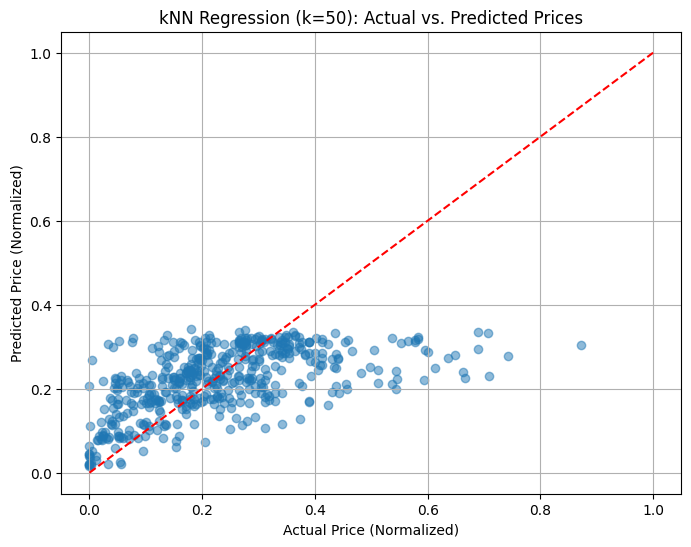

k = 100, MSE = 0.0156


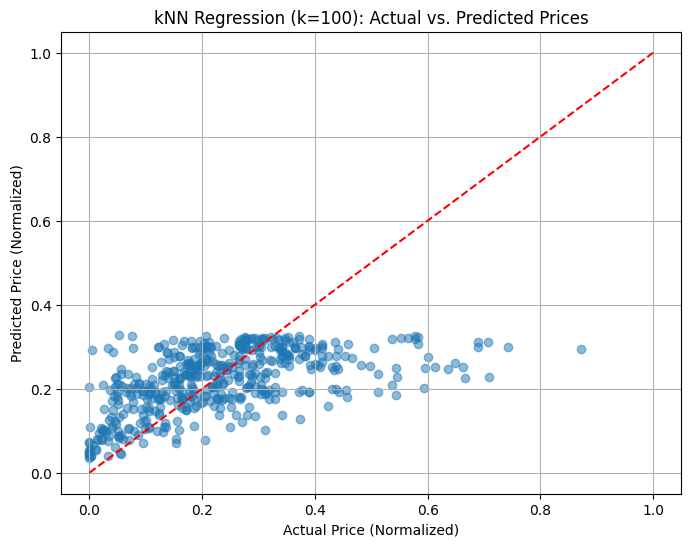

k = 300, MSE = 0.0159


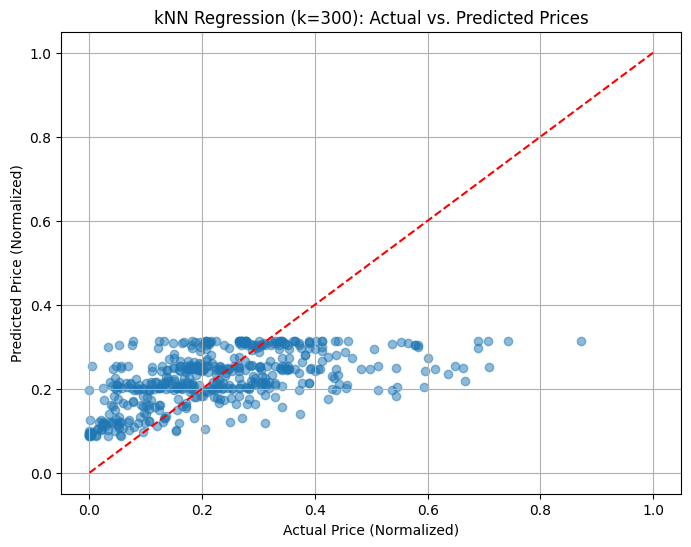

In [29]:
#Q2.3&4 use KNN algorithm and training data to predict price useing year and mileage for the test set of k-3,10,25,50,100,300
# For each k value, compute MSE and print scatter plot showing test value plotted against predicted
#Patterns?
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

X=df[['year','mileage']]
y=df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k_values = [3, 10, 25, 50, 100, 300]

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'k = {k}, MSE = {mse:.4f}')

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel('Actual Price (Normalized)')
    plt.ylabel('Predicted Price (Normalized)')
    plt.title(f'kNN Regression (k={k}): Actual vs. Predicted Prices')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Red dashed line for ideal prediction
    plt.grid(True)
    plt.show()
#Q2.5
# k=50 is the best k-value. I am noticing that as k increasing, the predicted value is more likely to be .2 regardless of the actual.


#Q2.6
# Describe what happened in the plots of predicted versus actual prices as  k  varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)
# When k was low, the points were more varied and when k was high they were more tight but in the same region regardless of x. The 'sweet spot' is in the middle (k=50). This is a direct example of over and under fitting data. When it is over fit, it confidently says the wrong result; when it is udner fit, it is vague and gives scatter results.


**Q3.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

     animal  hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  \
0  aardvark     1         0     0     1         0        0         1        1   
1  antelope     1         0     0     1         0        0         0        1   
2      bass     0         0     1     0         0        1         1        1   
3      bear     1         0     0     1         0        0         1        1   
4      boar     1         0     0     1         0        0         1        1   

   backbone  breathes  venomous  fins  legs  tail  domestic  catsize  class  
0         1         1         0     0     4     0         0        1      1  
1         1         1         0     0     4     1         0        1      1  
2         1         0         0     1     0     1         0        0      4  
3         1         1         0     0     4     0         0        1      1  
4         1         1         0     0     4     1         0        1      1  
(101, 18)
      animal  hair  feathers  eggs 

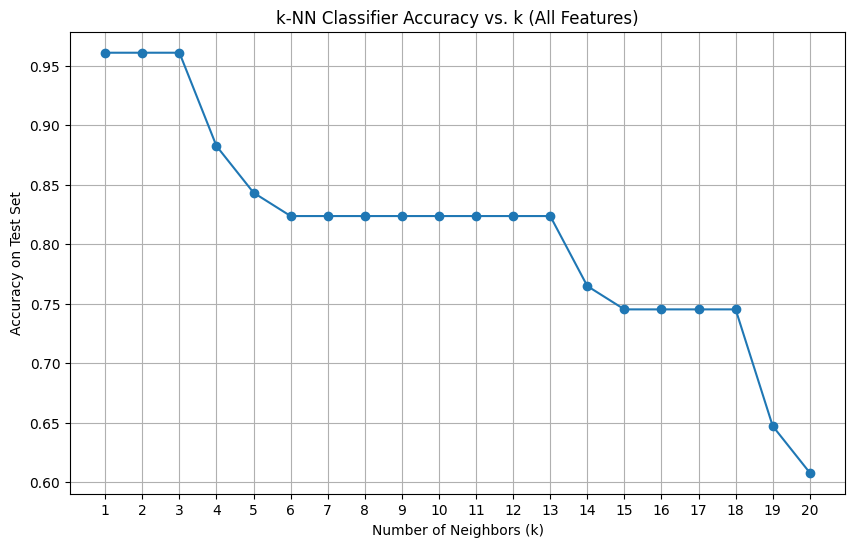

The optimal k appears to be: 1 with an accuracy of 0.9608
Accuracy of the optimal k-NN model (k=1): 0.9608


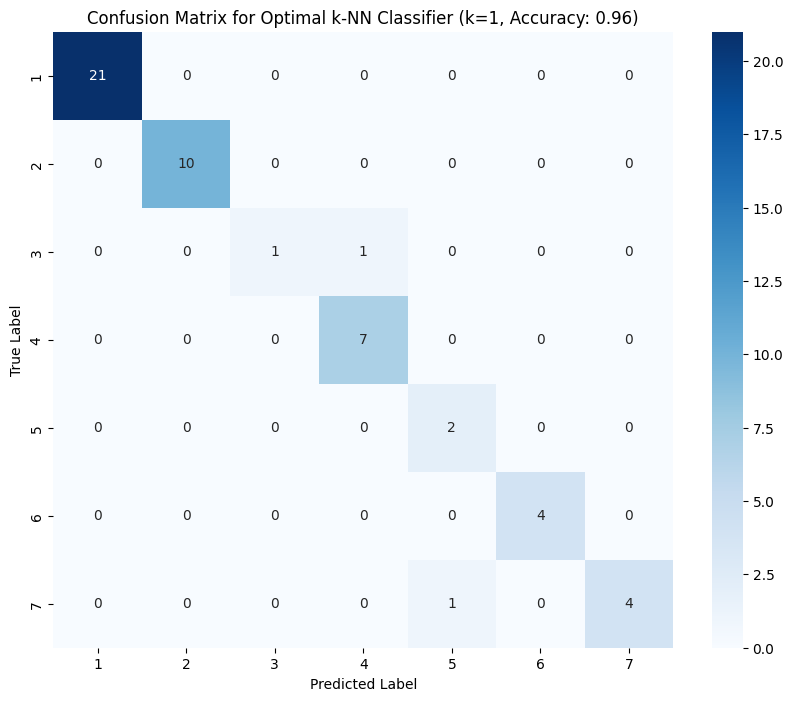

In [41]:
new_url=('https://raw.githubusercontent.com/nickgoering/KNN/refs/heads/main/data/zoo.csv')
df_animals=pd.read_csv(new_url)
print(df_animals.head())
print(df_animals.shape)
#df_animals
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

#Q3.1
# print all animals of class 1
print(df_animals[df_animals['class']==1])
class_var=1
while (class_var!=8):
  print(df_animals[df_animals['class']==class_var])
  class_var+=1
#How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
print("Class Distribution:")
print(df_animals['class'].value_counts().sort_index())

# How much variation is there in each of the features/covariates?

# Exclude 'animal' and 'class' columns
features = df_animals.drop(columns=['animal', 'class']).columns

for feature in features:
    print(f"\n--- Feature: {feature} ---")
    print(df_animals[feature].value_counts())
    if df_animals[feature].nunique() > 2: # For non-binary features like 'legs'
        print(f"  Unique values: {df_animals[feature].unique()}")
        print(f"  Mean: {df_animals[feature].mean():.2f}")
        print(f"  Std: {df_animals[feature].std():.2f}")

# class 1: milk, backbone, breathes (Mammal)
# class 2: feathers & eggs (birds possibily)
# class 3: reptiles
# Class 4: fish
# Class 5: frogs/toads/etc
# Class 6: evil things (flying insects that are not cool)
# class 7:sea animals without fins (not fish)

#Q3.2
# Prepare features (X) and target (y)
# Drop 'animal' as it's a name and 'class' as it's the target
X_all = df_animals.drop(columns=['animal', 'class'])
y_all = df_animals['class']

# Split data 50/50 into training and test sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.5, random_state=42, stratify=y_all)

print(f"Training set shape: {X_train_all.shape}")
print(f"Testing set shape: {X_test_all.shape}")
print("\nTraining set class distribution:")
print(y_train_all.value_counts().sort_index())
print("\nTesting set class distribution:")
print(y_test_all.value_counts().sort_index())
# Determine optimal k by evaluating accuracy on the test set for a range of k values
k_range = range(1, 21) # Test k from 1 to 20
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_all, y_train_all)
    y_pred_all = knn.predict(X_test_all)
    accuracies.append(accuracy_score(y_test_all, y_pred_all))

# Plotting accuracy vs. k
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy on Test Set')
plt.title('k-NN Classifier Accuracy vs. k (All Features)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# Find the optimal k
optimal_k_index = np.argmax(accuracies)
optimal_k = k_range[optimal_k_index]
print(f"The optimal k appears to be: {optimal_k} with an accuracy of {accuracies[optimal_k_index]:.4f}")

# Explanation for selecting k:
# We select k by training the k-NN model with different values of k on the training data and evaluating its performance (accuracy) on the test data.
# The value of k that yields the highest accuracy on the test set is chosen as the optimal k. This helps to find a balance between bias and variance, preventing both overfitting (too small k) and underfitting (too large k).

# Train the k-NN classifier with the optimal k
optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_knn.fit(X_train_all, y_train_all)
y_pred_optimal = optimal_knn.predict(X_test_all)

# Calculate accuracy
accuracy_optimal = accuracy_score(y_test_all, y_pred_optimal)
print(f"Accuracy of the optimal k-NN model (k={optimal_k}): {accuracy_optimal:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_all, y_pred_optimal)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_all.unique()),
            yticklabels=sorted(y_all.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Optimal k-NN Classifier (k={optimal_k}, Accuracy: {accuracy_optimal:.2f})')
plt.show()

# Interpretation of mistakes (from class labels printed earlier):
# Identify which true classes are being misclassified as which predicted classes by looking at the off-diagonal elements of the confusion matrix.
# For example, if many animals from Class X (e.g., fish) are predicted as Class Y (e.g., amphibians), this indicates that their features are very similar or the model struggles to differentiate them.
# Given the nature of the animal features (binary characteristics), some classes might share many similar traits, leading to confusion.
# For instance, some aquatic mammals (e.g., dolphin in class 1) might be confused with fish (class 4) if features like `milk` or `breathes` are not sufficiently weighted or if `aquatic` dominates.
# Similarly, small differences in features like `legs` or `fins` might lead to confusion between related groups like reptiles (class 3) and amphibians (class 5) or certain invertebrates (class 7).

**Q4.** Write your own function to make a kernel density plot.

- The user should pass in a Pandas series or Numpy array.
- The default kernel should be Gaussian, but include the uniform/bump and Epanechnikov as alternatives.
- The default bandwidth should be the Silverman plug-in, but allow the user to specify an alternative.
- You can use Matplotlib or Seaborn's `.lineplot`, but not an existing function that creates kernel density plots.

You will have to make a lot of choices and experiment with getting errors. Embrace the challenge and track your choices in the comments in your code.

Use a data set from class to show that your function works, and compare it with the Seaborn `kdeplot`.

We covered the Gaussian,
$$
k(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^2/2}
$$
and uniform
$$
k(z) = \begin{cases}
\frac{1}{2}, & |z| \le 1 \\
0, & |z|>1
\end{cases}
$$
kernels in class, but the Epanechnikov kernel is
$$
k(z) = \begin{cases}
\frac{3}{4} (1-z^2), & |z| \le 1 \\
0, & |z|>1.
\end{cases}
$$

In order to make your code run reasonably quickly, consider using the `pdist` or `cdist` functions from SciPy to make distance calculations for arrays of points. The other leading alternative is to thoughtfully use NumPy's broadcasting features. Writing `for` loops will be slow, but that's fine.

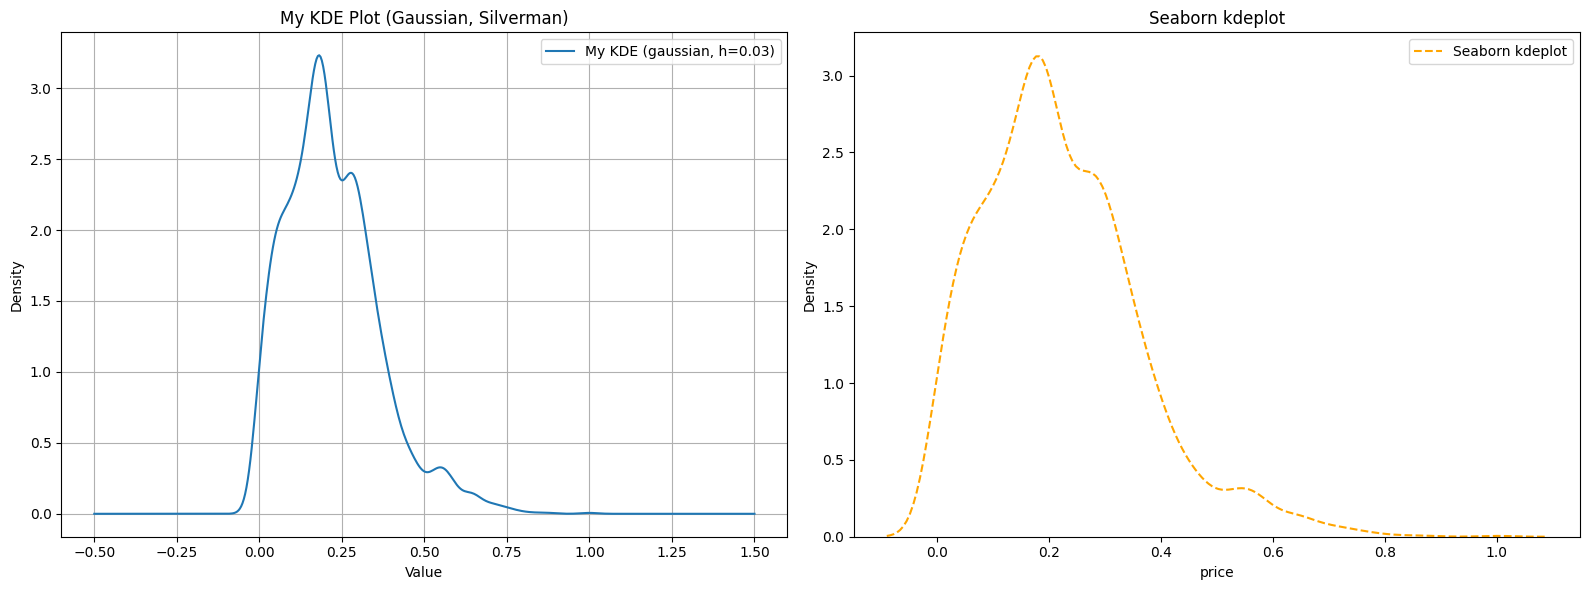


Demonstrating different kernels and custom bandwidths:


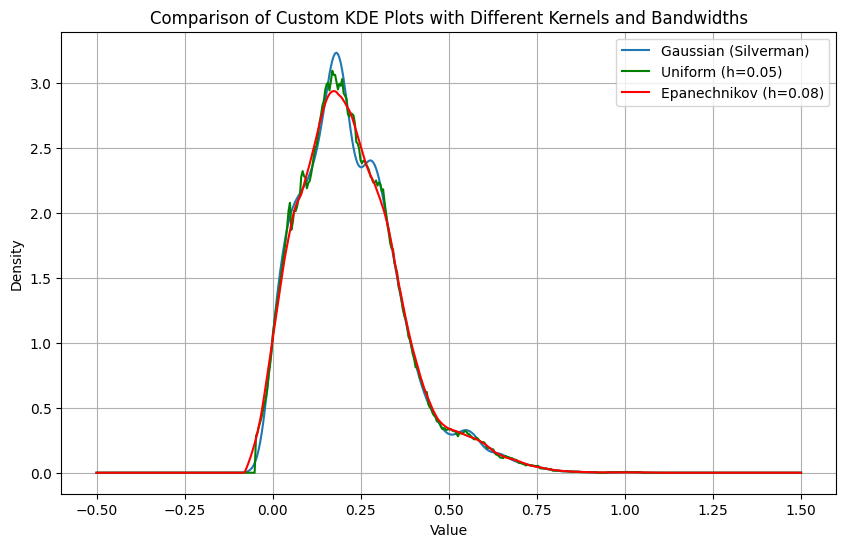

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr

def gaussian_kernel(z):
    """Gaussian kernel function."""
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

def uniform_kernel(z):
    """Uniform (boxcar) kernel function."""
    return np.where(np.abs(z) <= 1, 0.5, 0.0)

def epanechnikov_kernel(z):
    """Epanechnikov kernel function."""
    return np.where(np.abs(z) <= 1, 0.75 * (1 - z**2), 0.0)

def silverman_bandwidth(data):
    """Calculates Silverman's rule of thumb bandwidth."""
    n = len(data)
    std = np.std(data)
    # Use min(std, IQR/1.34) as the spread measure for robustness
    A = min(std, iqr(data) / 1.34)
    return 0.9 * A * n**(-0.2)

def my_kde_plot(data, kernel='gaussian', bandwidth='silverman', ax=None, label=None, color=None, linestyle=None):
    """
    Generates a Kernel Density Estimate (KDE) plot.

    Args:
        data (pd.Series or np.ndarray): The input data for which to compute the KDE.
        kernel (str): The type of kernel to use: 'gaussian', 'uniform', or 'epanechnikov'.
                      Defaults to 'gaussian'.
        bandwidth (str or float): The bandwidth parameter. If 'silverman', uses Silverman's rule of thumb.
                                  Otherwise, a float value can be provided. Defaults to 'silverman'.
        ax (matplotlib.axes.Axes, optional): The axes on which to draw the plot. If None, uses current axes.
        label (str, optional): Label for the plot legend.
        color (str, optional): Color of the plot line.
        linestyle (str, optional): Line style of the plot.
    """
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    elif not isinstance(data, np.ndarray):
        raise TypeError("Input data must be a Pandas Series or NumPy array.")

    # Determine evaluation points for the KDE
    data_min, data_max = data.min(), data.max()
    # Extend range slightly to capture tail densities
    x_grid = np.linspace(data_min - (data_max - data_min) * 0.5,
                         data_max + (data_max - data_min) * 0.5, 500)

    # Determine bandwidth
    if bandwidth == 'silverman':
        h = silverman_bandwidth(data)
    elif isinstance(bandwidth, (int, float)) and bandwidth > 0:
        h = bandwidth
    else:
        raise ValueError("Bandwidth must be 'silverman' or a positive float.")

    # Select kernel function
    kernel_funcs = {
        'gaussian': gaussian_kernel,
        'uniform': uniform_kernel,
        'epanechnikov': epanechnikov_kernel
    }
    selected_kernel = kernel_funcs.get(kernel)
    if selected_kernel is None:
        raise ValueError(f"Unknown kernel type: {kernel}. Choose from {list(kernel_funcs.keys())}")

    # Calculate KDE using broadcasting
    # diff is a (len(x_grid), len(data)) array
    diff = (x_grid[:, np.newaxis] - data) / h
    # kernel_values applies the kernel to each element of diff
    kernel_values = selected_kernel(diff)
    # kde_values sums across the data points and normalizes
    kde_values = np.sum(kernel_values, axis=1) / (len(data) * h)

    # Plotting
    if ax is None:
        ax = plt.gca() # Get current axes

    ax.plot(x_grid, kde_values, label=f'My KDE ({kernel}, h={h:.2f})' if label is None else label,
            color=color, linestyle=linestyle)

    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title('Kernel Density Estimate')
    ax.legend()
    ax.grid(True)


# --- Demonstration ---

# Using the 'price' column from the 'df' (USA_cars_datasets) for demonstration
# Ensure df exists and 'price' column is available
if 'df' in globals() and 'price' in df.columns:
    sample_data = df['price'].dropna() # Drop NA values for KDE
    if not sample_data.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Plot with my_kde_plot (Gaussian kernel, Silverman bandwidth)
        my_kde_plot(sample_data, kernel='gaussian', bandwidth='silverman', ax=axes[0])
        axes[0].set_title('My KDE Plot (Gaussian, Silverman)')

        # Compare with Seaborn's kdeplot
        sns.kdeplot(sample_data, ax=axes[1], label='Seaborn kdeplot', color='orange', linestyle='--')
        axes[1].set_title('Seaborn kdeplot')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        # --- Further Demonstrations with different kernels and bandwidths ---
        print("\nDemonstrating different kernels and custom bandwidths:")
        fig2, ax2 = plt.subplots(figsize=(10, 6))
        my_kde_plot(sample_data, kernel='gaussian', bandwidth='silverman', ax=ax2, label='Gaussian (Silverman)')
        my_kde_plot(sample_data, kernel='uniform', bandwidth=0.05, ax=ax2, label='Uniform (h=0.05)', color='green')
        my_kde_plot(sample_data, kernel='epanechnikov', bandwidth=0.08, ax=ax2, label='Epanechnikov (h=0.08)', color='red')
        ax2.set_title('Comparison of Custom KDE Plots with Different Kernels and Bandwidths')
        plt.show()
    else:
        print("The 'price' column is empty after dropping NA values. Cannot perform KDE.")
else:
    print("DataFrame 'df' or 'price' column not found. Please ensure it's loaded and processed.")

